### Project Setup and Titanic Dataset Loading

In [1]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="pastel")

SEED = 42
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

### Titanic dataset – Data Analysis

 **Target variable (Survived)**:

  `0 = did not survive`, `1 = survived`.

- **Missing data**:  
  Most missing values in *Cabin*, some in *Age*, few in *Embarked*.

- **Numerical features**:  
  - *Age*: younger passengers (children) survived more often.  
  - *Fare*: higher fare → higher survival (linked to 1st class).  
  - *SibSp* / *Parch*: traveling alone reduced survival chances.

- **Categorical features**:  
  - *Pclass*: 1st class had higher survival than 2nd/3rd.  
  - *Sex*: women had much higher survival rates than men.  
  - *Embarked*: weaker effect, but Cherbourg passengers survived more often.

- **Correlations**:  
  Survival positively related to *Fare*, negatively to *Pclass* and *Age*.  
  Family variables (*SibSp*, *Parch*) show weaker correlations individually.

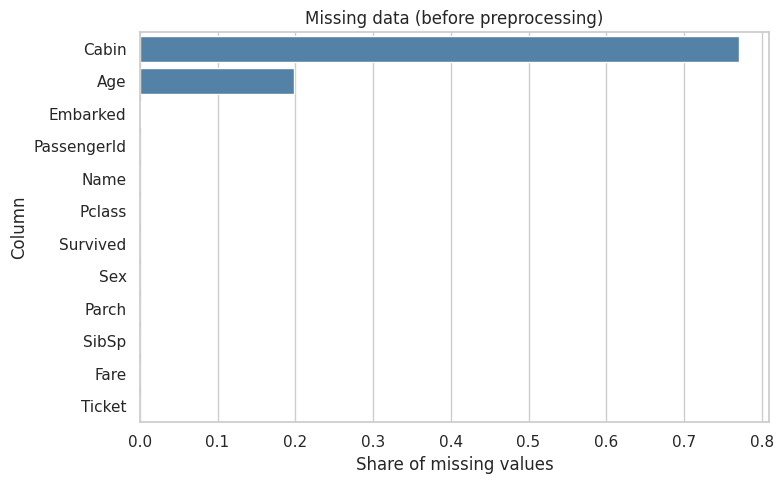

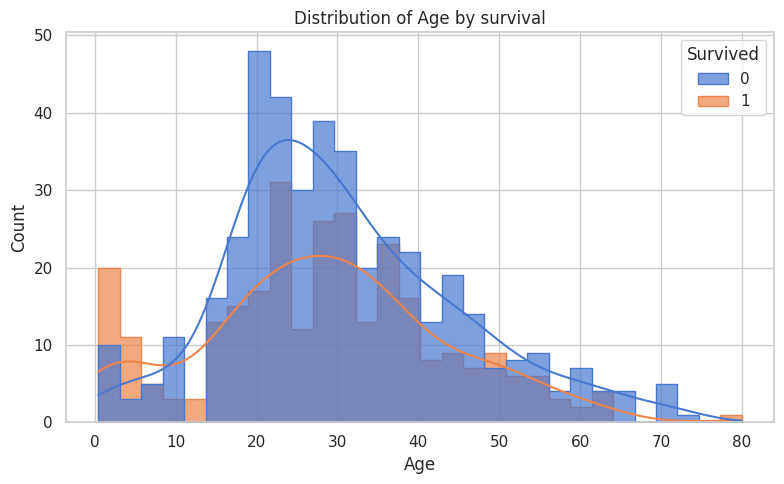

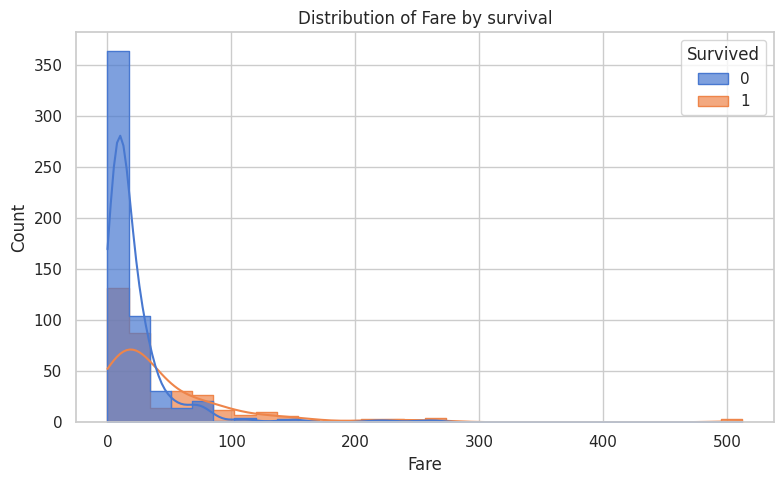

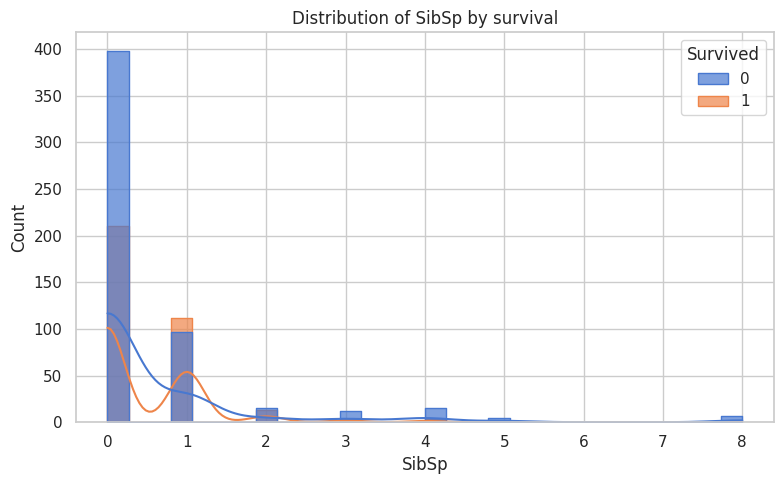

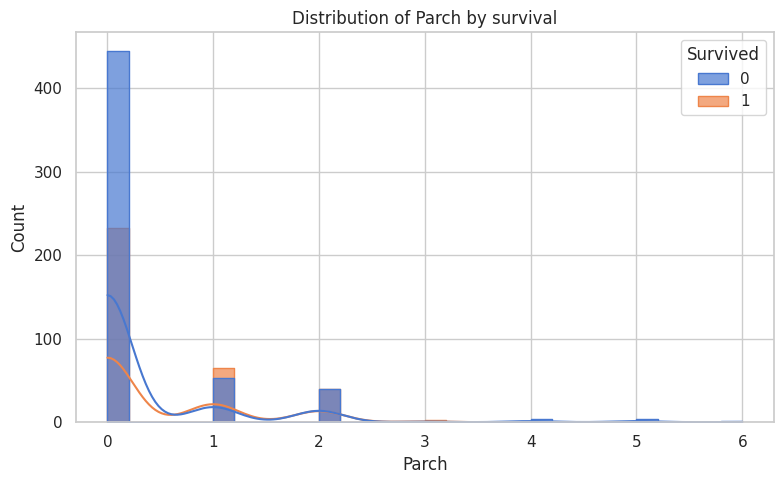

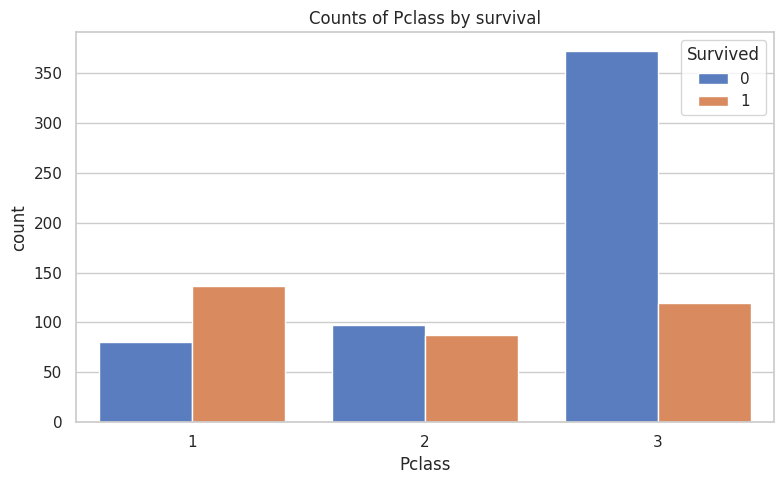

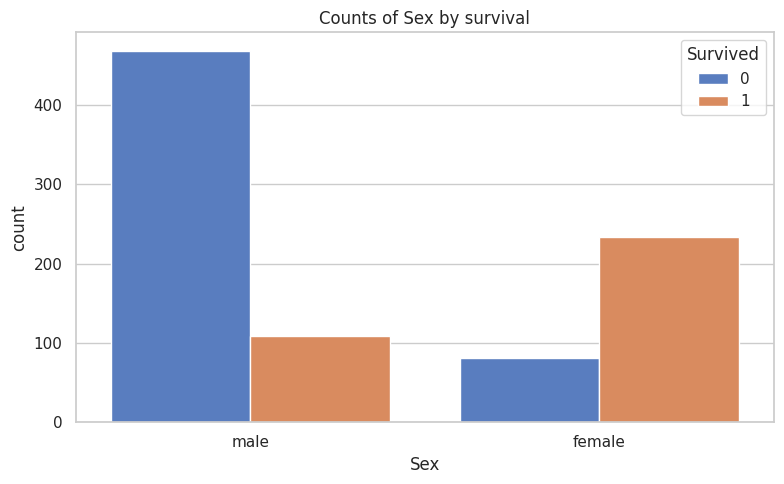

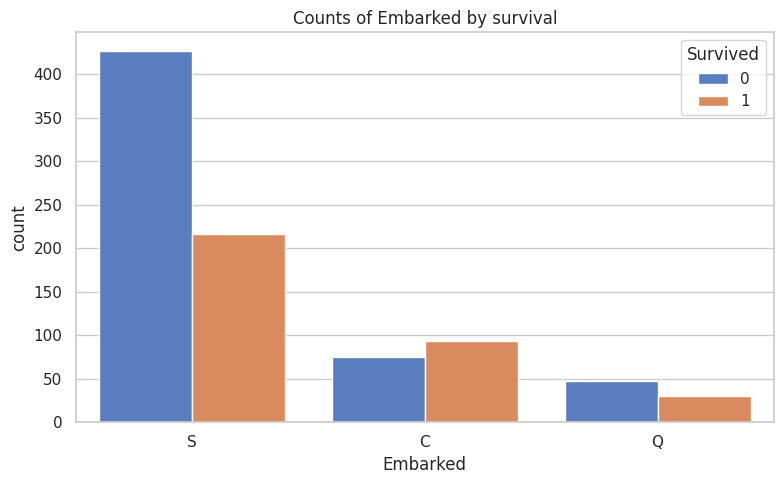

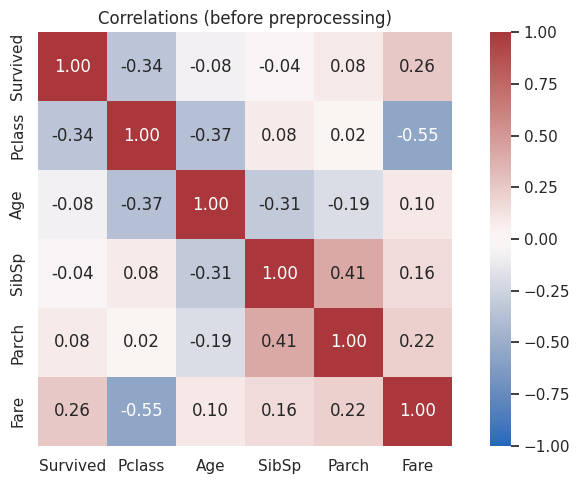

In [ ]:
plt.figure(figsize=(8,5))
missing = df.isna().mean().sort_values(ascending=False).reset_index()
missing.columns = ['column', 'missing_ratio']
sns.barplot(data=missing, x='missing_ratio', y='column', color='steelblue')
plt.xlabel('Share of missing values')
plt.ylabel('Column')
plt.title('Missing data (before preprocessing)')
plt.tight_layout()

num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
for c in num_cols:
    plt.figure(figsize=(8,5))
    sns.histplot(
        data=df, x=c, hue='Survived', bins=30, kde=True,
        element='step', palette='muted', alpha=0.7
    )
    plt.title(f'Distribution of {c} by survival')
    plt.tight_layout()

cat_cols = ['Pclass', 'Sex', 'Embarked']
for c in cat_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x=c, hue='Survived', palette='muted')
    plt.title(f'Counts of {c} by survival')
    plt.tight_layout()

plt.figure(figsize=(8,5))
corr = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr()
sns.heatmap(
    corr, annot=True, fmt='.2f', square=True, cbar=True,
    cmap='vlag', vmin=-1, vmax=1
)
plt.title('Correlations (before preprocessing)')
plt.tight_layout()

### Feature Engineering and Preprocessing Pipeline

In [2]:
class Featurizer(BaseEstimator, TransformerMixin):
  def fit(self, X, y=None):
    return self
  def transform(self, X):
    X = X.copy()
    X['has_age'] = X['Age'].isna().astype(int)
    X['has_cabin'] = X['Cabin'].notna().astype(int)
    X['Title'] = X['Name'].str.extract(' ([A-Za-z]+)\\.', expand=False)
    X['Title'] = X['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    X['Title'] = X['Title'].replace('Mlle', 'Miss')
    X['Title'] = X['Title'].replace('Ms', 'Miss')
    X['Title'] = X['Title'].replace('Mme', 'Mrs')
    X['Fare_log'] = np.log1p(X['Fare'])
    X['FamilySize'] = X['SibSp'] + X['Parch'] + 1
    X['IsAlone'] = (X['FamilySize'] == 1).astype(int)
    X['IsChild'] = (X['Age'] <= 16).astype(int)
    X['IsMother'] = ((X['Sex'] == 'female') & (X['Parch'] > 0) & (X['Age'] > 18) & (X['Title'] != 'Miss')).astype(int)
    X['FarePerPerson'] = X['Fare'] / (X['FamilySize'])
    X['FarePerPerson_log'] = np.log1p(X['FarePerPerson'])
    X['Deck'] = X['Cabin'].str[0].fillna('U')
    X['SexNum'] = (X['Sex'] == 'female').astype(int)
    X['Pclass_x_Sex'] = X['Pclass'] * X['SexNum']
    X['Pclass_x_FarePP'] = X['Pclass'] * X['FarePerPerson_log'].fillna(0)

    return X

X = df.drop(columns=['Survived'])
y = df['Survived']

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=SEED, stratify=y_train_val
)

numeric_features = ['Age', 'Fare_log', 'Pclass', 'SibSp', 'Parch', 'has_age', 'has_cabin',
                    'FamilySize', 'IsAlone', 'IsChild', 'IsMother', 'FarePerPerson_log', 'SexNum', 'Pclass_x_Sex', 'Pclass_x_FarePP']
categorical_features = ['Sex', 'Embarked', 'Title', 'Deck']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler(with_mean=True)),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='drop'
    )


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


### Building Classification Models and Evaluating Performance with Cross-Validation

In [ ]:
scoring = {'auc': 'roc_auc', 'acc': 'accuracy', 'prec': 'precision', 'rec': 'recall', 'f1': 'f1'}

clf_logreg = Pipeline(steps=[
    ('featurizer', Featurizer()),
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=SEED)),
])

clf_rf = Pipeline(steps=[
    ('featurizer', Featurizer()),
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=400, max_depth=None, random_state=SEED)),
])

cv_res_lr = cross_validate(clf_logreg, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
cv_res_rf = cross_validate(clf_rf, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)

def summarize(cvres, name):
  m = {k: (np.mean(v), np.std(v)) for k, v in cvres.items() if k.startswith('test_')}
  return {'model': name, **{k.replace('test_',''): f'{m[k][0]:.4f} ± {m[k][1]:.4f}' for k in m}}

summary = pd.DataFrame([summarize(cv_res_lr, 'LogisticRegression'), summarize(cv_res_rf, 'RandomForest')])
print(summary)

clf_logreg.fit(X_train, y_train)
proba_lr = clf_logreg.predict_proba(X_val)[:, 1]
pred_lr = (proba_lr >= 0.5).astype(int)
acc_lr = accuracy_score(y_val, pred_lr)
auc_lr = roc_auc_score(y_val, proba_lr)

clf_rf.fit(X_train, y_train)
proba_rf = clf_rf.predict_proba(X_val)[:, 1]
pred_rf = (proba_rf >= 0.5).astype(int)
acc_rf = accuracy_score(y_val, pred_rf)
auc_rf = roc_auc_score(y_val, proba_rf)

print({'LogReg_test_acc': round(acc_lr,4), 'LogReg_test_auc': round(auc_lr,4), 'RF_test_acc': round(acc_rf,4), 'RF_test_auc': round(auc_rf,4)})


                model              auc              acc             prec  \
0  LogisticRegression  0.8749 ± 0.0251  0.8278 ± 0.0118  0.8164 ± 0.0449   
1        RandomForest  0.8633 ± 0.0378  0.8067 ± 0.0202  0.7689 ± 0.0483   

               rec               f1  
0  0.7161 ± 0.0419  0.7609 ± 0.0155  
1  0.7161 ± 0.0626  0.7387 ± 0.0297  
{'LogReg_test_acc': 0.8182, 'LogReg_test_auc': np.float64(0.8683), 'RF_test_acc': 0.8182, 'RF_test_auc': np.float64(0.8606)}


### Selecting the Best Model on Validation and Assessing Final Performance on Test Set

Wybrany model: LogisticRegression (val AUC: 0.8683)
{'best_clf_acc': 0.838, 'best_clf_auc': np.float64(0.8576)}


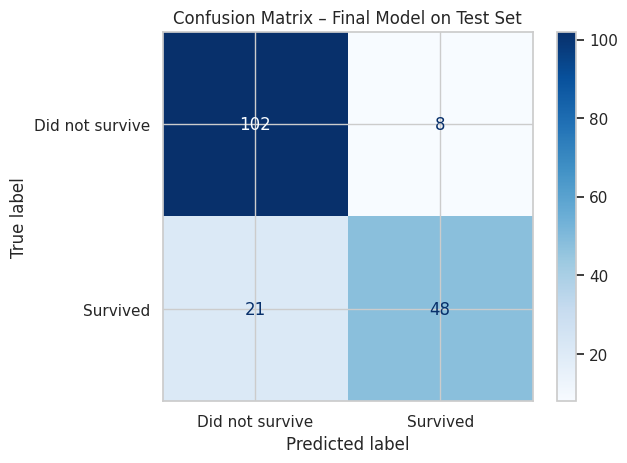

In [ ]:
best_name = 'RandomForest' if auc_rf >= auc_lr else 'LogisticRegression'
best_clf = clf_rf if auc_rf >= auc_lr else clf_logreg
print(f'Wybrany model: {best_name} (val AUC: {max(auc_rf, auc_lr):.4f})')

best_clf.fit(X_train_val, y_train_val)

proba_test = best_clf.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)
acc = accuracy_score(y_test, pred_test)
auc = roc_auc_score(y_test, proba_test)

print({'best_clf_acc': round(acc,4), 'best_clf_auc': round(auc,4)})

cm = confusion_matrix(y_test, pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did not survive', 'Survived'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix – Final Model on Test Set')
plt.show()